# Simple Federated Learning (FL) on MNIST

This notebook demonstrates a minimal, educational Federated Learning pipeline implemented from scratch in PyTorch. It trains a small MLP centrally (baseline) and then simulates multiple clients that perform local training and Federated Averaging. The notebook is intentionally lightweight so it runs quickly on a CPU.

SPRINT 1


## Imports

In [21]:
import copy
import math
import random
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

# Reproducibility
random.seed(0)
torch.manual_seed(0)

## Dataset loading

In [22]:
# On entraîne le modèle par petits groupes de 64 images
BATCH_SIZE = 64
NUM_WORKERS = 0  # pour l'instant

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# MNIST transforms
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Split entre train et test
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader_full = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print('Train samples:', len(train_dataset), 'Test samples:', len(test_dataset))

Device: cpu
Train samples: 60000 Test samples: 10000


Dans cette partie, je charge le dataset MNIST et je prépare les données pour l’entraînement.

Les données sont transformées en tenseurs et normalisées afin d’améliorer les performances du modèle.

Ensuite, j’utilise des DataLoaders pour traiter les données par batch, ce qui permet un entraînement plus efficace.

## Le modèle (SimpleMLP)

In [23]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() #transformation vers un vecteur
        self.fc1 = nn.Linear(28 * 28, 128) # 1ere couche
        self.fc2 = nn.Linear(128, 64) # 2eme couche
        self.out = nn.Linear(64, 10) # couche de sortie 

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

# nouveau modèle pour chaque client
def create_model():
    return SimpleMLP()

J’utilise un réseau de neurones de type MLP.

L’image est d’abord transformée en vecteur, puis elle passe à travers plusieurs couches linéaires avec des fonctions d’activation ReLU.

La dernière couche produit une sortie de dimension 10 correspondant aux classes possibles.

## Entraînement, Évaluation et Split

In [24]:
def evaluate(model: nn.Module, dataloader: DataLoader, device: torch.device) -> Tuple[float, float]:
    """Return (loss, accuracy) on the provided dataloader.
    Model is expected to be in eval() mode when called.
    """
    model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc

def train_one_epoch(model: nn.Module, dataloader: DataLoader, optimizer, device: torch.device) -> None:
    model.to(device)
    model.train()
    criterion = nn.CrossEntropyLoss()
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

def split_dataset_iid(dataset, num_clients: int) -> List[Subset]:
    """fonction pour diviser un ensemble de données en sous-ensembles IID pour
    chaque client
    """
    total_len = len(dataset)
    base = total_len // num_clients
    lengths = [base] * num_clients
    rem = total_len - base * num_clients
    # distribuer les éléments restants (s'il y en a) aux premiers clients
    for i in range(rem):
        lengths[i] += 1
    # créer des sous-ensembles
    subsets = random_split(dataset, lengths)
    return list(subsets)

## Résumé des fonctions

- **evaluate** : calcule la loss et l’accuracy du modèle (sans entraînement)
- **train_one_epoch** : entraîne le modèle sur une époque
- **split_dataset_iid** : divise les données en plusieurs clients (IID)

## Entraînement centralisé

In [25]:
# nouveau modèle pour chaque client
central_model = create_model().to(device)
optimizer = torch.optim.SGD(central_model.parameters(), lr=0.1) 
CENTRAL_EPOCHS = 2  

for epoch in range(1, CENTRAL_EPOCHS + 1):
    train_one_epoch(central_model, train_loader_full, optimizer, device)
    loss, acc = evaluate(central_model, test_loader, device)
    print(f'Centralized Epoch {epoch}/{CENTRAL_EPOCHS} -> Test loss: {loss:.4f}, Test acc: {acc:.4f}')

central_loss, central_acc = evaluate(central_model, test_loader, device)
print(
    'Centralized baseline final -> Loss: {:.4f}, Acc: {:.4f}'.format(
        central_loss, central_acc
    )
)

Centralized Epoch 1/2 -> Test loss: 0.1702, Test acc: 0.9472
Centralized Epoch 2/2 -> Test loss: 0.0954, Test acc: 0.9700
Centralized baseline final -> Loss: 0.0954, Acc: 0.9700




Dans cette étape, un modèle est entraîné de manière classique sur l’ensemble du dataset.

Le modèle est initialisé puis entraîné pendant plusieurs époques à l’aide d’un optimiseur (SGD).  
À chaque époque, les performances sont évaluées sur le jeu de test afin de suivre l’évolution de la loss et de l’accuracy.

Cette étape permet d’obtenir une **baseline de référence**, qui sera ensuite comparée aux performances du modèle entraîné en Federated Learning.

## Simulation des clients (IID split)

In [26]:
NUM_CLIENTS = 5  
client_subsets = split_dataset_iid(train_dataset, NUM_CLIENTS)
client_loaders = [DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS) for subset in client_subsets]
client_sizes = [len(s) for s in client_subsets]
print('Client data sizes (IID):', client_sizes)

Client data sizes (IID): [12000, 12000, 12000, 12000, 12000]


## Local training (clients train for 1 epoch)

In [27]:
def local_train_update(global_state_dict, train_loader: DataLoader, device: torch.device, lr: float = 0.1, epochs: int = 1):
    """ fonction de mise à jour de l'entraînement local
    """
    model = create_model()
    model.load_state_dict(global_state_dict)
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    for e in range(epochs):
        train_one_epoch(model, train_loader, optimizer, device)
    return model.state_dict(), len(train_loader.dataset)

# test de la mise à jour locale
test_state, test_samples = local_train_update(central_model.state_dict(), client_loaders[0], device, lr=0.1, epochs=1)
print('Local training produced state dict keys:', list(test_state.keys())[:5], 'num samples:', test_samples)

Local training produced state dict keys: ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'out.weight'] num samples: 12000




Dans cette étape, chaque client reçoit une copie du modèle global et l’entraîne localement sur ses propres données.

Le modèle est initialisé avec les poids globaux, puis entraîné pendant un nombre limité d’époques.  
Une fois l’entraînement terminé, les nouveaux paramètres du modèle ainsi que le nombre d’échantillons utilisés sont retournés au serveur.

Cette étape est essentielle dans le Federated Learning, car elle permet à chaque client d’apprendre à partir de ses données locales sans les partager.

## Federated Averaging (agrégation des modèles)

In [47]:
def federated_average(state_dicts: List[dict], weights: List[float]) -> dict:
    """ fonction d'average des poids des modèles 
    """
    # normalise les poids
    total = float(sum(weights))
    if total == 0:
        raise ValueError('Sum of weights must be > 0')
    norm_weights = [w / total for w in weights]

    avg_state = {}
    for key in state_dicts[0].keys():
        # 🔥 CAS FLOAT → on moyenne normalement
        if state_dicts[0][key].dtype.is_floating_point:
            avg_state[key] = torch.zeros_like(state_dicts[0][key])
            for sd, w in zip(state_dicts, norm_weights):
                avg_state[key] += sd[key] * w
        
        # 🔥 CAS NON-FLOAT (BatchNorm etc) → on copie
        else:
            avg_state[key] = state_dicts[0][key]

    # remettre les types d'origine (inutile mais on garde ta logique)
    for key in avg_state.keys():
        avg_state[key] = avg_state[key].type(state_dicts[0][key].dtype)

    return avg_state


Dans cette étape, les modèles entraînés par chaque client sont combinés pour former un modèle global.

Les paramètres des modèles locaux sont moyennés en tenant compte du nombre de données de chaque client.  
Cette méthode, appelée Federated Averaging, permet d’intégrer les connaissances de tous les clients sans partager leurs données.

C’est une étape clé du Federated Learning, car elle permet de construire un modèle global à partir d’apprentissages locaux.

## Boucle de Federated Learning

In [29]:
ROUNDS = 3  
FED_LR = 0.1  # valeur d'apprentissage local pour les clients
global_model = create_model()
global_state = global_model.state_dict()

# Suivi de la précision par round
round_results = []
for r in range(1, ROUNDS + 1):
    print(f'--- Federated Round {r}/{ROUNDS} ---')
    local_states = []
    local_sizes = []
    # chaque client s'entraîne localement pendant 1 époque et renvoie ses poids mis à jour
    for i, loader in enumerate(client_loaders):
        sd, n_samples = local_train_update(global_state, loader, device, lr=FED_LR, epochs=1)
        local_states.append(sd)
        local_sizes.append(n_samples)
        print(f' Client {i+1}: trained on {n_samples} samples')
    # Agrégation
    new_global_state = federated_average(local_states, local_sizes)
    global_state = new_global_state
    global_model.load_state_dict(global_state)
    # Évaluation sur le jeu de test
    loss, acc = evaluate(global_model, test_loader, device)
    round_results.append((loss, acc))
    print(f' Round {r} -> Test loss: {loss:.4f}, Test acc: {acc:.4f}')

--- Federated Round 1/3 ---
 Client 1: trained on 12000 samples
 Client 2: trained on 12000 samples
 Client 3: trained on 12000 samples
 Client 4: trained on 12000 samples
 Client 5: trained on 12000 samples
 Round 1 -> Test loss: 0.2911, Test acc: 0.9126
--- Federated Round 2/3 ---
 Client 1: trained on 12000 samples
 Client 2: trained on 12000 samples
 Client 3: trained on 12000 samples
 Client 4: trained on 12000 samples
 Client 5: trained on 12000 samples
 Round 2 -> Test loss: 0.1952, Test acc: 0.9425
--- Federated Round 3/3 ---
 Client 1: trained on 12000 samples
 Client 2: trained on 12000 samples
 Client 3: trained on 12000 samples
 Client 4: trained on 12000 samples
 Client 5: trained on 12000 samples
 Round 3 -> Test loss: 0.1631, Test acc: 0.9488




Dans cette étape, le Federated Learning est exécuté sur plusieurs rounds.

À chaque round, le modèle global est envoyé à chaque client, qui l’entraîne localement sur ses données.  
Les modèles locaux sont ensuite récupérés et agrégés à l’aide de Federated Averaging pour mettre à jour le modèle global.

Les performances du modèle global sont évaluées après chaque round afin d’observer son amélioration progressive.

## Analyse des résultats

In [30]:
print('Centralized baseline -> Loss: {:.4f}, Acc: {:.4f}'.format(central_loss, central_acc))
for i, (loss, acc) in enumerate(round_results, 1):
    print(f'Federated Round {i}: Test Loss = {loss:.4f}, Test Acc = {acc:.4f}')

final_fed_loss, final_fed_acc = round_results[-1]
print('Summary:')
print(f' Centralized acc: {central_acc:.4f}')
print(f' Federated (after {ROUNDS} rounds) acc: {final_fed_acc:.4f}')

Centralized baseline -> Loss: 0.0954, Acc: 0.9700
Federated Round 1: Test Loss = 0.2911, Test Acc = 0.9126
Federated Round 2: Test Loss = 0.1952, Test Acc = 0.9425
Federated Round 3: Test Loss = 0.1631, Test Acc = 0.9488
Summary:
 Centralized acc: 0.9700
 Federated (after 3 rounds) acc: 0.9488




Les résultats montrent que le modèle centralisé atteint une accuracy de 97.0 %, tandis que le modèle fédéré atteint 94.88 % après 3 rounds.

On observe une amélioration progressive des performances du modèle fédéré à chaque round, ce qui indique une convergence du modèle global grâce à l’agrégation des modèles locaux.

Cependant, le modèle fédéré reste légèrement moins performant que le modèle centralisé, ce qui est attendu car chaque client ne dispose que d’une partie des données.

Ces résultats illustrent le compromis entre performance et confidentialité dans le Federated Learning.

# Sprint 2


# Setup

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

# Helper pour lancer FL

In [32]:
def run_federated(client_loaders, rounds=3, lr=0.1):
    global_model = create_model()
    global_state = global_model.state_dict()
    
    results = []
    
    for r in range(rounds):
        local_states = []
        local_sizes = []
        
        for loader in client_loaders:
            sd, n = local_train_update(global_state, loader, device, lr=lr, epochs=1)
            local_states.append(sd)
            local_sizes.append(n)
        
        global_state = federated_average(local_states, local_sizes)
        global_model.load_state_dict(global_state)
        
        loss, acc = evaluate(global_model, test_loader, device)
        results.append(acc)
    
    return results



Cette fonction implémente le processus de Federated Learning :

1. Initialisation du modèle global  
2. Entraînement local sur chaque client  
3. Agrégation des modèles locaux  
4. Évaluation du modèle global  

Elle permet de simuler un environnement distribué réaliste.

# IID baseline


In [33]:
client_subsets_iid = split_dataset_iid(train_dataset, NUM_CLIENTS)

client_loaders_iid = [
    DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)
    for subset in client_subsets_iid
]

results_iid = run_federated(client_loaders_iid)

print("IID results:", results_iid)

IID results: [0.9206, 0.9388, 0.9519]




Dans ce scénario, les données sont réparties de manière IID (indépendante et identiquement distribuée) entre les clients.

Ce cas sert de référence, car il correspond à une situation idéale où chaque client possède une distribution similaire des données.

# NON-IID (par classes)

In [34]:
def split_noniid_classes(dataset, num_clients=5):
    targets = np.array(dataset.targets)
    class_splits = np.array_split(np.arange(10), num_clients)
    
    subsets = []
    for classes in class_splits:
        idx = np.where(np.isin(targets, classes))[0]
        subsets.append(Subset(dataset, idx))
    
    return subsets

client_subsets_noniid = split_noniid_classes(train_dataset, NUM_CLIENTS)

client_loaders_noniid = [
    DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)
    for subset in client_subsets_noniid
]

results_noniid = run_federated(client_loaders_noniid)

print("Non-IID (classes) results:", results_noniid)

/var/folders/zv/2djxbbx13ysbr2pfl27pgp680000gn/T/ipykernel_18778/1603531400.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


Non-IID (classes) results: [0.26, 0.614, 0.6591]



Dans ce scénario, chaque client reçoit uniquement certaines classes.

Cela simule un cas réaliste où les données sont fortement hétérogènes.

Exemple :
- Client 1 : chiffres 0–2  
- Client 2 : chiffres 3–5  

Ce cas est particulièrement difficile pour le Federated Learning.

# NON-IID (déséquilibré)

In [35]:
def split_noniid_imbalanced(dataset, num_clients=5):
    total_len = len(dataset)
    proportions = [0.6, 0.2, 0.1, 0.05, 0.05]
    
    indices = np.random.permutation(total_len)
    splits = (np.array(proportions) * total_len).astype(int)
    
    subsets = []
    start = 0
    for s in splits:
        subsets.append(Subset(dataset, indices[start:start+s]))
        start += s
    
    return subsets

client_subsets_imbalanced = split_noniid_imbalanced(train_dataset, NUM_CLIENTS)

client_loaders_imbalanced = [
    DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)
    for subset in client_subsets_imbalanced
]

results_imbalanced = run_federated(client_loaders_imbalanced)

print("Non-IID (imbalanced) results:", results_imbalanced)

Non-IID (imbalanced) results: [0.9346, 0.9603, 0.9668]




Les données sont réparties de manière inégale entre les clients.

Certains clients possèdent beaucoup plus de données que d'autres.

Ce scénario permet d’étudier l’impact du déséquilibre sur l’apprentissage global.

# IMPACT NOMBRE DE CLIENTS

In [36]:
client_tests = [3, 5, 10]
results_clients = {}

for n_clients in client_tests:
    subsets = split_dataset_iid(train_dataset, n_clients)
    
    loaders = [
        DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)
        for subset in subsets
    ]
    
    res = run_federated(loaders)
    results_clients[n_clients] = res[-1]

print(results_clients)

{3: 0.9623, 5: 0.9524, 10: 0.934}




Cette expérience étudie l’effet du nombre de clients sur les performances du modèle.

Une augmentation du nombre de clients entraîne :
- une fragmentation des données  
- une complexité accrue de l’agrégation  

Cela permet d’analyser la scalabilité du Federated Learning.

# IMPACT NOMBRE DE ROUNDS

In [37]:
round_tests = [3, 5, 10]
results_rounds = {}

for r in round_tests:
    res = run_federated(client_loaders_iid, rounds=r)
    results_rounds[r] = res[-1]

print(results_rounds)

{3: 0.9502, 5: 0.963, 10: 0.9723}




Cette section analyse l’influence du nombre d’itérations (rounds) de Federated Learning.

Un plus grand nombre de rounds permet généralement :
- une meilleure convergence  
- une amélioration progressive du modèle global  

# GRAPH PRINCIPAL

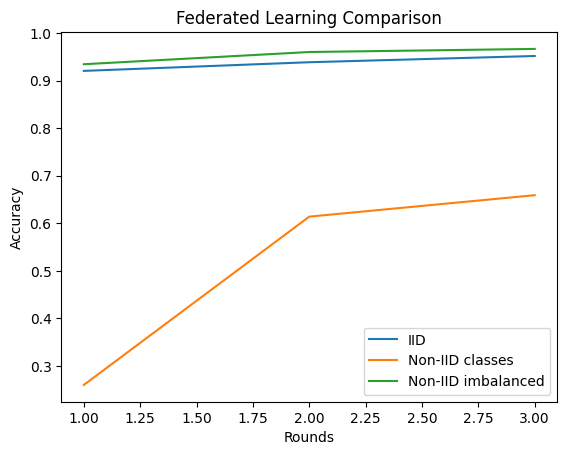

In [38]:
rounds = range(1, len(results_iid) + 1)

plt.plot(rounds, results_iid, label="IID")
plt.plot(rounds, results_noniid, label="Non-IID classes")
plt.plot(rounds, results_imbalanced, label="Non-IID imbalanced")

plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("Federated Learning Comparison")
plt.legend()
plt.show()



Ce graphique compare les performances du modèle dans différents contextes :

- IID  
- Non-IID par classes  
- Non-IID déséquilibré  

Il permet de visualiser l’impact de la distribution des données sur l’apprentissage.

# GRAPH CLIENTS

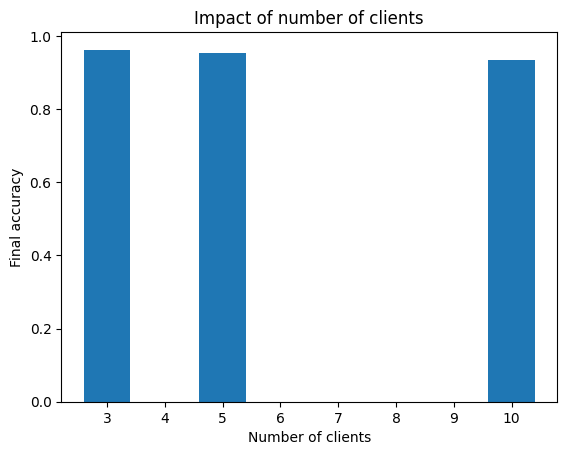

In [39]:
plt.bar(results_clients.keys(), results_clients.values())

plt.xlabel("Number of clients")
plt.ylabel("Final accuracy")
plt.title("Impact of number of clients")
plt.show()



Ce graphique montre l’évolution des performances en fonction du nombre de clients.

Il met en évidence les limites du Federated Learning lorsque le nombre de participants augmente.

# GRAPH ROUNDS

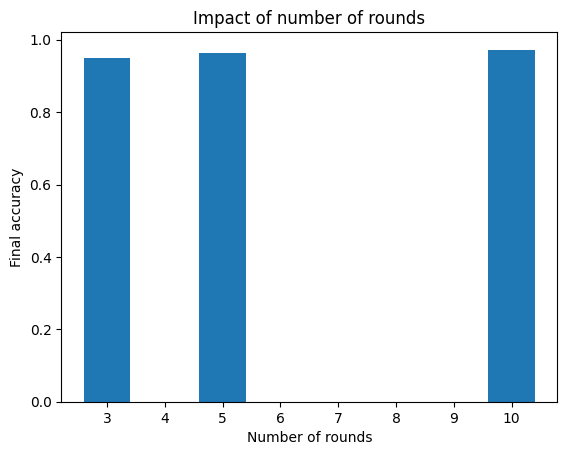

In [40]:
plt.bar(results_rounds.keys(), results_rounds.values())

plt.xlabel("Number of rounds")
plt.ylabel("Final accuracy")
plt.title("Impact of number of rounds")
plt.show()



Ce graphique illustre l’amélioration des performances en fonction du nombre de rounds.

Il permet d’observer la convergence du modèle global.

In [41]:
class CNN_V1(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 28 -> 14
        x = self.pool(F.relu(self.conv2(x)))   # 14 -> 7
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x



Ce premier modèle convolutionnel sert de baseline.

Il permet de capturer la structure spatiale des images, contrairement au MLP utilisé précédemment.

Architecture :
- 2 couches convolutionnelles  
- pooling  
- couches fully connected  

In [42]:
def create_model():
    return CNN_V1()


===== IID =====
Round 1 accuracy: 0.9424
Round 2 accuracy: 0.9734
Round 3 accuracy: 0.9830
Round 4 accuracy: 0.9848
Round 5 accuracy: 0.9871

===== NON-IID (CLASSES) =====


/var/folders/zv/2djxbbx13ysbr2pfl27pgp680000gn/T/ipykernel_18778/1858339662.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


Round 1 accuracy: 0.3168
Round 2 accuracy: 0.6238
Round 3 accuracy: 0.6311
Round 4 accuracy: 0.8305
Round 5 accuracy: 0.8513

===== NON-IID (IMBALANCED) =====
Round 1 accuracy: 0.9635
Round 2 accuracy: 0.9855
Round 3 accuracy: 0.9878
Round 4 accuracy: 0.9893
Round 5 accuracy: 0.9865

===== FINAL RESULTS =====
IID final accuracy: 0.9871
Non-IID classes final accuracy: 0.8513
Non-IID imbalanced final accuracy: 0.9865


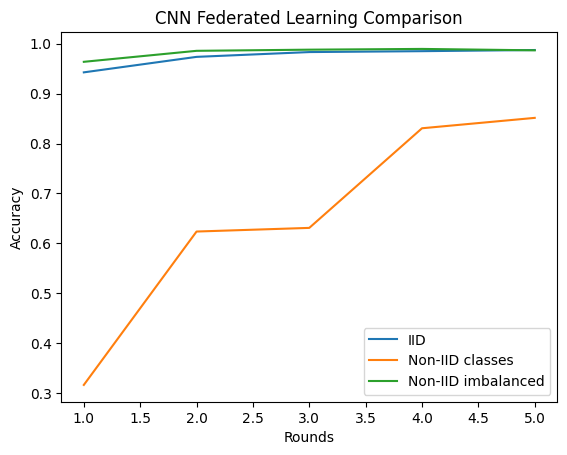

In [43]:
# =========================
# TEST CNN V1 (FULL ANALYSIS)
# =========================

def evaluate_full(model, dataloader, device):
    model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    
    return correct / total


def run_federated_detailed(client_loaders, rounds=5, lr=0.1):
    global_model = create_model()
    global_state = global_model.state_dict()
    
    acc_per_round = []
    
    for r in range(rounds):
        local_states = []
        local_sizes = []
        
        for loader in client_loaders:
            sd, n = local_train_update(global_state, loader, device, lr=lr, epochs=1)
            local_states.append(sd)
            local_sizes.append(n)
        
        global_state = federated_average(local_states, local_sizes)
        global_model.load_state_dict(global_state)
        
        acc = evaluate_full(global_model, test_loader, device)
        acc_per_round.append(acc)
        
        print(f"Round {r+1} accuracy: {acc:.4f}")
    
    return acc_per_round


# =========================
# SPLITS
# =========================

def split_noniid_classes(dataset, num_clients=5):
    targets = np.array(dataset.targets)
    class_splits = np.array_split(np.arange(10), num_clients)
    
    subsets = []
    for classes in class_splits:
        idx = np.where(np.isin(targets, classes))[0]
        subsets.append(Subset(dataset, idx))
    
    return subsets


def split_noniid_imbalanced(dataset, num_clients=5):
    total_len = len(dataset)
    proportions = [0.6, 0.2, 0.1, 0.05, 0.05]
    
    indices = np.random.permutation(total_len)
    splits = (np.array(proportions) * total_len).astype(int)
    
    subsets = []
    start = 0
    for s in splits:
        subsets.append(Subset(dataset, indices[start:start+s]))
        start += s
    
    return subsets


# =========================
# RUN EXPERIMENTS
# =========================

NUM_CLIENTS = 5

# IID
client_subsets_iid = split_dataset_iid(train_dataset, NUM_CLIENTS)
client_loaders_iid = [DataLoader(s, batch_size=BATCH_SIZE, shuffle=True) for s in client_subsets_iid]

print("\n===== IID =====")
iid_results = run_federated_detailed(client_loaders_iid)

# Non-IID classes
client_subsets_noniid = split_noniid_classes(train_dataset, NUM_CLIENTS)
client_loaders_noniid = [DataLoader(s, batch_size=BATCH_SIZE, shuffle=True) for s in client_subsets_noniid]

print("\n===== NON-IID (CLASSES) =====")
noniid_results = run_federated_detailed(client_loaders_noniid)

# Non-IID imbalanced
client_subsets_imbalanced = split_noniid_imbalanced(train_dataset, NUM_CLIENTS)
client_loaders_imbalanced = [DataLoader(s, batch_size=BATCH_SIZE, shuffle=True) for s in client_subsets_imbalanced]

print("\n===== NON-IID (IMBALANCED) =====")
imbalanced_results = run_federated_detailed(client_loaders_imbalanced)


# =========================
# SUMMARY
# =========================

print("\n===== FINAL RESULTS =====")
print(f"IID final accuracy: {iid_results[-1]:.4f}")
print(f"Non-IID classes final accuracy: {noniid_results[-1]:.4f}")
print(f"Non-IID imbalanced final accuracy: {imbalanced_results[-1]:.4f}")


# =========================
# GRAPH
# =========================

rounds = range(1, len(iid_results) + 1)

plt.plot(rounds, iid_results, label="IID")
plt.plot(rounds, noniid_results, label="Non-IID classes")
plt.plot(rounds, imbalanced_results, label="Non-IID imbalanced")

plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("CNN Federated Learning Comparison")
plt.legend()
plt.show()



Le modèle est testé dans différents scénarios :

- IID  
- Non-IID par classes  
- Non-IID déséquilibré  

Cela permet d’évaluer sa robustesse dans un contexte de Federated Learning.

In [44]:
class CNN_V2(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Feature extraction
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Classifier
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x



Ce modèle introduit :

- Batch Normalization pour stabiliser l’apprentissage  
- Dropout pour améliorer la généralisation  

Cependant, ces techniques peuvent poser problème en Federated Learning non-IID.

In [45]:
def create_model():
    return CNN_V2()


TESTING CNN_V2

===== IID =====
Round 1 accuracy: 0.8193
Round 2 accuracy: 0.9743
Round 3 accuracy: 0.9804
Round 4 accuracy: 0.9827
Round 5 accuracy: 0.9858

===== NON-IID (CLASSES) =====


/var/folders/zv/2djxbbx13ysbr2pfl27pgp680000gn/T/ipykernel_18778/2971879406.py:60: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


Round 1 accuracy: 0.1078
Round 2 accuracy: 0.1028
Round 3 accuracy: 0.1028
Round 4 accuracy: 0.1135
Round 5 accuracy: 0.1135

===== NON-IID (IMBALANCED) =====
Round 1 accuracy: 0.9675
Round 2 accuracy: 0.9730
Round 3 accuracy: 0.9826
Round 4 accuracy: 0.9854
Round 5 accuracy: 0.9883

===== FINAL RESULTS =====
IID final accuracy: 0.9858
Non-IID classes final accuracy: 0.1135
Non-IID imbalanced final accuracy: 0.9883


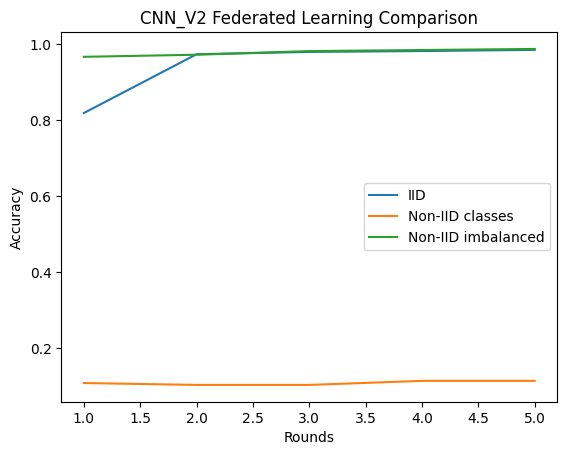

In [48]:
# =========================
# TEST CNN_V2 (FULL ANALYSIS)
# =========================

def evaluate_full(model, dataloader, device):
    model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    
    return correct / total


def run_federated_detailed(client_loaders, rounds=5, lr=0.1, local_epochs=1):
    global_model = create_model()
    global_state = global_model.state_dict()
    
    acc_per_round = []
    
    for r in range(rounds):
        local_states = []
        local_sizes = []
        
        for loader in client_loaders:
            sd, n = local_train_update(
                global_state,
                loader,
                device,
                lr=lr,
                epochs=local_epochs
            )
            local_states.append(sd)
            local_sizes.append(n)
        
        global_state = federated_average(local_states, local_sizes)
        global_model.load_state_dict(global_state)
        
        acc = evaluate_full(global_model, test_loader, device)
        acc_per_round.append(acc)
        
        print(f"Round {r+1} accuracy: {acc:.4f}")
    
    return acc_per_round


# =========================
# SPLITS
# =========================

def split_noniid_classes(dataset, num_clients=5):
    targets = np.array(dataset.targets)
    class_splits = np.array_split(np.arange(10), num_clients)
    
    subsets = []
    for classes in class_splits:
        idx = np.where(np.isin(targets, classes))[0]
        subsets.append(Subset(dataset, idx))
    
    return subsets


def split_noniid_imbalanced(dataset, num_clients=5):
    total_len = len(dataset)
    proportions = [0.6, 0.2, 0.1, 0.05, 0.05]
    
    indices = np.random.permutation(total_len)
    splits = (np.array(proportions) * total_len).astype(int)
    
    subsets = []
    start = 0
    for s in splits:
        subsets.append(Subset(dataset, indices[start:start+s]))
        start += s
    
    return subsets


# =========================
# RUN EXPERIMENTS
# =========================

NUM_CLIENTS = 5

print("\n========================")
print("TESTING CNN_V2")
print("========================")

# IID
client_subsets_iid = split_dataset_iid(train_dataset, NUM_CLIENTS)
client_loaders_iid = [DataLoader(s, batch_size=BATCH_SIZE, shuffle=True) for s in client_subsets_iid]

print("\n===== IID =====")
iid_results = run_federated_detailed(client_loaders_iid, rounds=5)

# Non-IID classes
client_subsets_noniid = split_noniid_classes(train_dataset, NUM_CLIENTS)
client_loaders_noniid = [DataLoader(s, batch_size=BATCH_SIZE, shuffle=True) for s in client_subsets_noniid]

print("\n===== NON-IID (CLASSES) =====")
noniid_results = run_federated_detailed(client_loaders_noniid, rounds=5)

# Non-IID imbalanced
client_subsets_imbalanced = split_noniid_imbalanced(train_dataset, NUM_CLIENTS)
client_loaders_imbalanced = [DataLoader(s, batch_size=BATCH_SIZE, shuffle=True) for s in client_subsets_imbalanced]

print("\n===== NON-IID (IMBALANCED) =====")
imbalanced_results = run_federated_detailed(client_loaders_imbalanced, rounds=5)


# =========================
# SUMMARY
# =========================

print("\n===== FINAL RESULTS =====")
print(f"IID final accuracy: {iid_results[-1]:.4f}")
print(f"Non-IID classes final accuracy: {noniid_results[-1]:.4f}")
print(f"Non-IID imbalanced final accuracy: {imbalanced_results[-1]:.4f}")


# =========================
# GRAPH
# =========================

rounds = range(1, len(iid_results) + 1)

plt.plot(rounds, iid_results, label="IID")
plt.plot(rounds, noniid_results, label="Non-IID classes")
plt.plot(rounds, imbalanced_results, label="Non-IID imbalanced")

plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("CNN_V2 Federated Learning Comparison")
plt.legend()
plt.show()



Cette section analyse l’impact de BatchNorm et Dropout.

Les résultats permettent de comprendre les limites de certaines techniques classiques du deep learning dans un contexte distribué.

In [49]:
class CNN_V3(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Feature extraction
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Classifier
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 28 → 14
        x = self.pool(F.relu(self.conv2(x)))   # 14 → 7
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x



Ce modèle est conçu spécifiquement pour le Federated Learning :

- Suppression de BatchNorm  
- Utilisation de Dropout uniquement  

Objectif : améliorer la robustesse en contexte non-IID.

In [50]:
def create_model():
    return CNN_V3()


TESTING CNN_V3

===== IID =====
Round 1 accuracy: 0.9555
Round 2 accuracy: 0.9741
Round 3 accuracy: 0.9809
Round 4 accuracy: 0.9836
Round 5 accuracy: 0.9857

===== NON-IID (CLASSES) =====


/var/folders/zv/2djxbbx13ysbr2pfl27pgp680000gn/T/ipykernel_18778/2971879406.py:60: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


Round 1 accuracy: 0.5266
Round 2 accuracy: 0.6748
Round 3 accuracy: 0.7924
Round 4 accuracy: 0.8442
Round 5 accuracy: 0.8323

===== NON-IID (IMBALANCED) =====
Round 1 accuracy: 0.9608
Round 2 accuracy: 0.9819
Round 3 accuracy: 0.9878
Round 4 accuracy: 0.9881
Round 5 accuracy: 0.9895

===== FINAL RESULTS =====
IID final accuracy: 0.9857
Non-IID classes final accuracy: 0.8323
Non-IID imbalanced final accuracy: 0.9895


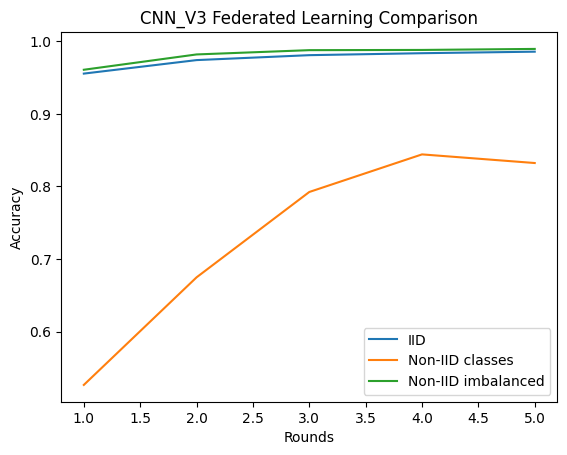

In [51]:
# =========================
# TEST CNN_V3 (FL ANALYSIS)
# =========================

print("\n========================")
print("TESTING CNN_V3")
print("========================")

def evaluate_full(model, dataloader, device):
    model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    
    return correct / total


def run_federated_detailed(client_loaders, rounds=5, lr=0.1, local_epochs=1):
    global_model = create_model()
    global_state = global_model.state_dict()
    
    acc_per_round = []
    
    for r in range(rounds):
        local_states = []
        local_sizes = []
        
        for loader in client_loaders:
            sd, n = local_train_update(
                global_state,
                loader,
                device,
                lr=lr,
                epochs=local_epochs
            )
            local_states.append(sd)
            local_sizes.append(n)
        
        global_state = federated_average(local_states, local_sizes)
        global_model.load_state_dict(global_state)
        
        acc = evaluate_full(global_model, test_loader, device)
        acc_per_round.append(acc)
        
        print(f"Round {r+1} accuracy: {acc:.4f}")
    
    return acc_per_round


# =========================
# SPLITS
# =========================

NUM_CLIENTS = 5

# IID
client_subsets_iid = split_dataset_iid(train_dataset, NUM_CLIENTS)
client_loaders_iid = [
    DataLoader(s, batch_size=BATCH_SIZE, shuffle=True)
    for s in client_subsets_iid
]

print("\n===== IID =====")
iid_results = run_federated_detailed(client_loaders_iid)

# Non-IID classes
client_subsets_noniid = split_noniid_classes(train_dataset, NUM_CLIENTS)
client_loaders_noniid = [
    DataLoader(s, batch_size=BATCH_SIZE, shuffle=True)
    for s in client_subsets_noniid
]

print("\n===== NON-IID (CLASSES) =====")
noniid_results = run_federated_detailed(client_loaders_noniid)

# Non-IID imbalanced
client_subsets_imbalanced = split_noniid_imbalanced(train_dataset, NUM_CLIENTS)
client_loaders_imbalanced = [
    DataLoader(s, batch_size=BATCH_SIZE, shuffle=True)
    for s in client_subsets_imbalanced
]

print("\n===== NON-IID (IMBALANCED) =====")
imbalanced_results = run_federated_detailed(client_loaders_imbalanced)


# =========================
# SUMMARY
# =========================

print("\n===== FINAL RESULTS =====")
print(f"IID final accuracy: {iid_results[-1]:.4f}")
print(f"Non-IID classes final accuracy: {noniid_results[-1]:.4f}")
print(f"Non-IID imbalanced final accuracy: {imbalanced_results[-1]:.4f}")


# =========================
# GRAPH
# =========================

rounds = range(1, len(iid_results) + 1)

plt.plot(rounds, iid_results, label="IID")
plt.plot(rounds, noniid_results, label="Non-IID classes")
plt.plot(rounds, imbalanced_results, label="Non-IID imbalanced")

plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("CNN_V3 Federated Learning Comparison")
plt.legend()
plt.show()



Ce modèle est évalué dans les mêmes conditions que les précédents.

Les résultats montrent une meilleure stabilité en contexte non-IID, tout en conservant de bonnes performances globales.